In [1]:
from bed.cli.main import run_experiment_from_config
import jax.numpy as jnp
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Experiment 1

In [46]:
results = run_experiment_from_config('experiment_5')

Running EIG Experiment: 100%|████████████████████████████████████████████████████| 100/100 [00:08<00:00, 11.44it/s, Global SD=1.66, Pool SD=2.11, Global RMSE=1.72, Pool RMSE=1.65, EIG=0.11]


In [68]:
def get_inter_predictions(r, ):
    predictions = []
    sd = []
    
    for f in r.filters:
        design_space = r.design_space
        x = jnp.linspace(design_space.min(), design_space.max())[...,None,None,None]
        y, cov = f.measurement_prior(x)
        predictions.append(y.squeeze())
        sd.append(jnp.sqrt(cov.squeeze()))

    predictions = jnp.array(predictions)
    sd = jnp.array(sd)
    return x, predictions , sd

def plot_eig_vs_epig_1d(r_epig,r_eig, iteration, figsize):
    x, predictions_epig, sd_epig = get_inter_predictions(r_epig)
    _, predictions_eig, sd_eig = get_inter_predictions(r_eig)
    x_epig = jnp.array(list(map(lambda x: x[0],r_epig.selected_designs)))
    y_epig = jnp.array(list(map(lambda x: x[1],r_epig.selected_designs)))
    x_eig = jnp.array(list(map(lambda x: x[0],r_eig.selected_designs)))
    y_eig = jnp.array(list(map(lambda x: x[1],r_eig.selected_designs)))
    y_true = r_epig.data.underlying_model(x)
    
    fig, axes = plt.subplots(1,2, figsize=figsize)
    fig.suptitle(f"1D Regression by {r_epig.filter_type.upper()}")   
    axes[0].plot(x.squeeze(), predictions_epig[iteration])
    axes[0].fill_between(x.squeeze(), (predictions_epig - 2*sd_epig)[iteration],(predictions_epig + 2*sd_epig)[iteration],alpha=.5)
    axes[0].scatter(x_epig,y_epig, color='r')
    axes[0].scatter(x_eig,y_eig, color='grey')
    axes[0].plot(x.squeeze(),y_true.squeeze(), color='black')
    axes[0].fill_betweenx( jnp.linspace(axes[0].get_ylim()[0],axes[0].get_ylim()[1]), 2,4, alpha=.5, color='g')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title('EPIG Strategy')
        
    axes[1].plot(x.squeeze(), predictions_eig[iteration])
    axes[1].fill_between(x.squeeze(), (predictions_eig - 2*sd_eig)[iteration],(predictions_eig + 2*sd_eig)[iteration],alpha=.5)
    axes[1].plot(x.squeeze(),y_true.squeeze(), color='black')
    axes[1].scatter(x_epig,y_epig, color='r')
    axes[1].scatter(x_eig,y_eig, color='grey')
    axes[1].set_xlabel('x')
    axes[1].set_title('EIG Strategy')
    axes[1].fill_betweenx( jnp.linspace(axes[1].get_ylim()[0],axes[1].get_ylim()[1]), 2,4, alpha=.5, color='g')
    

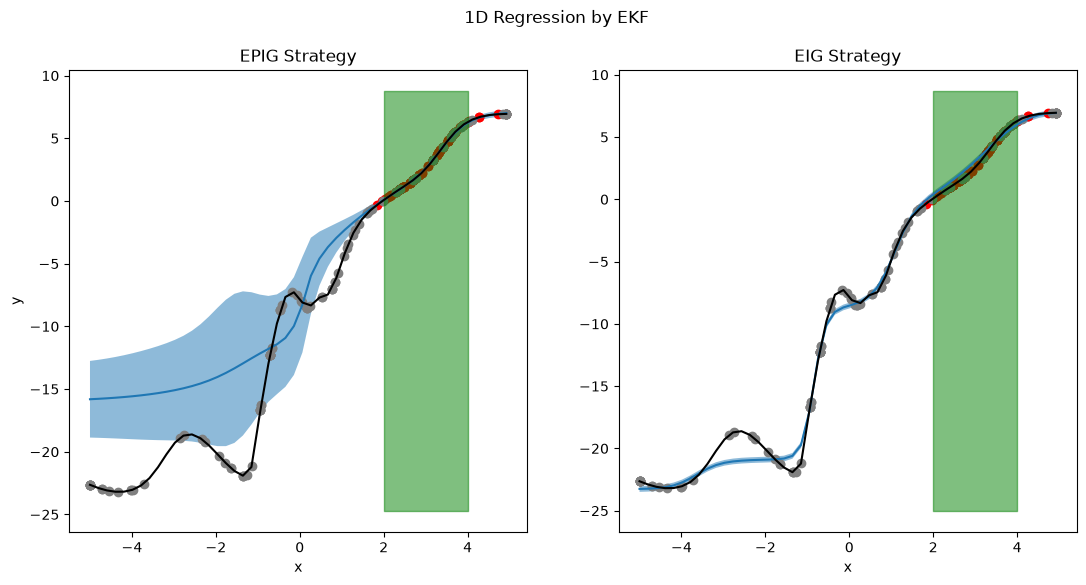

In [69]:
r_epig_ekf = results.experiment_results_dict['ekf']['EPIG']
r_eig_ekf = results.experiment_results_dict['ekf']['EIG']
plot_eig_vs_epig_1d(r_epig_ekf,r_eig_ekf, 99, (13,6))

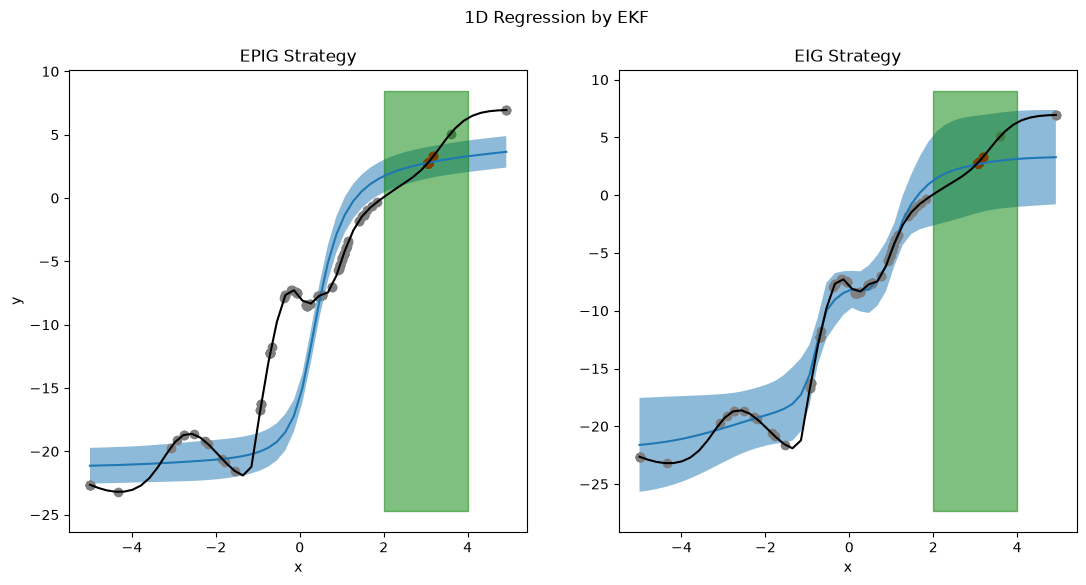

In [70]:
r_epig_ukf = results.experiment_results_dict['ukf']['EPIG']
r_eig_ukf = results.experiment_results_dict['ukf']['EIG']
plot_eig_vs_epig_1d(r_epig_ukf,r_eig_ukf, 99, (13,6))

# Experiment 2

In [ ]:
results = run_experiment_from_config('experiment_4')

Running EIG Experiment:  17%|████████▌                                        | 33/190 [00:15<01:15,  2.09it/s, Global SD=11.93, Pool SD=14.45, Global RMSE=15.01, Pool RMSE=11.01, EIG=0.23]

In [77]:
def plot_filter_performance(r_eig,r_epig, figsize):
    sd_glob_epig = r_epig.sd_glob
    sd_glob_eig = r_eig.sd_glob
    sd_pool_epig = r_epig.sd_pool
    sd_pool_eig = r_eig.sd_pool
    rmse_glob_epig = r_epig.rmse_glob
    rmse_glob_eig = r_eig.rmse_glob
    rmse_pool_epig = r_epig.rmse_pool
    rmse_pool_eig = r_eig.rmse_pool

    fig, axes = plt.subplots(2,2,figsize=figsize)
    axes[0,0].set_ylabel("SD")
    axes[0,0].set_title("Global Predictive Standard Deviation")
    axes[0,0].plot(sd_glob_epig)
    axes[0,0].plot(sd_glob_eig)
    axes[0,1].set_title("Pool Predictive Standard Deviation")
    axes[0,1].plot(sd_pool_epig)
    axes[0,1].plot(sd_pool_eig)
    axes[1,0].set_ylabel("RMSE")
    axes[1,0].set_title("Global RMSE")
    axes[1,0].plot(rmse_glob_epig)
    axes[1,0].plot(rmse_glob_eig)
    axes[1,1].set_title("Pool RMSE")
    axes[1,1].plot(rmse_pool_epig)
    axes[1,1].plot(rmse_pool_eig)
    

In [86]:
r_epig_ekf = results.experiment_results_dict['ekf']['EPIG']
r_eig_ekf = results.experiment_results_dict['ekf']['EIG']
r_epig_ukf = results.experiment_results_dict['ukf']['EPIG']
r_eig_ukf = results.experiment_results_dict['ukf']['EIG']



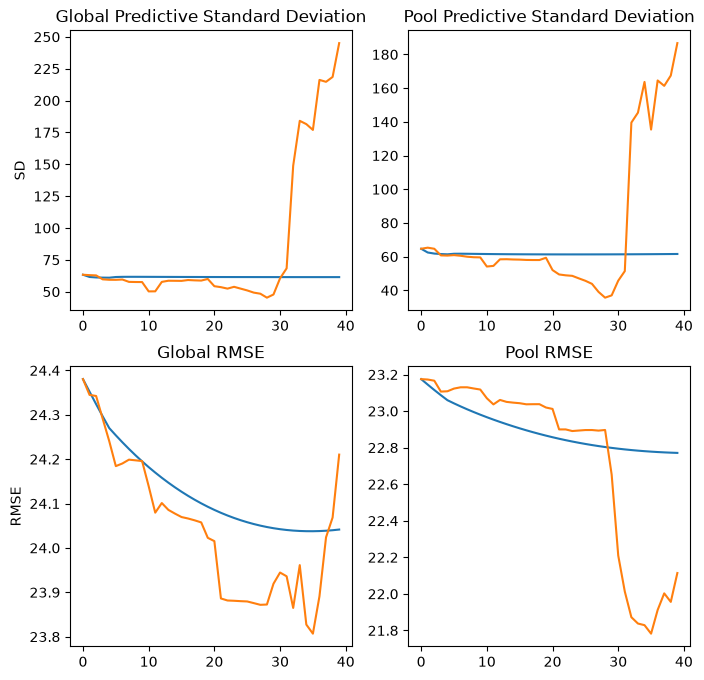

In [87]:
plot_filter_performance(r_eig_ukf, r_epig_ukf, (8,8))

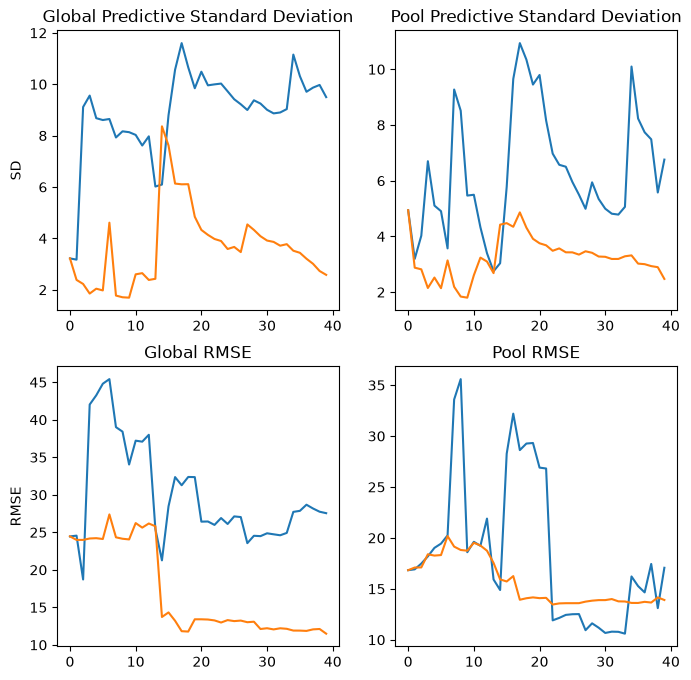

In [88]:
plot_filter_performance(r_eig_ekf, r_epig_ekf, (8,8))